<a href="https://colab.research.google.com/github/juacardonahe/Interactive-Color-Segmentation-LP/blob/main/ICIS_LP_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Interactive Color Image Segmentation with Linear Programming (LP)**
*Hongdong Li - Chunhua Shen* - 2008

[Interactive Color Image Segmentation with Linear Programming](https://doi.org/10.1007/s00138-008-0171-x)

---
#### **Creado por:** Juan José Cardona H.

## **Instalacion de librerias e imports generales**

In [ ]:
# Instalación de dependencias e imports principales
!pip install scikit-image matplotlib -q
!pip install ipympl scikit-learn -q

In [ ]:
!pip install scipy -q

In [ ]:
%matplotlib widget

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float, transform

import ipywidgets as widgets
from IPython.display import display, clear_output

from matplotlib.widgets import LassoSelector
from matplotlib.path import Path as MplPath

from sklearn.mixture import GaussianMixture

from scipy import sparse
from scipy.optimize import linprog

Support for third party widgets (widgets outside of the ipywidgets package) needs to be enabled separately. Support for these widgets will be loaded from a CDN external from Colab.

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

## **Fase 1 - Preprocesamiento y construcción del vector de características**

En esta fase se prepara la imagen de entrada para que pueda ser utilizada por las etapas posteriores del algoritmo de segmentación interactiva propuesto por *Li y Shen*. Los objetivos principales son:

1.   Cargar la imagen desde un enlace externo (por ejemplo, GitHub).
2.   Redimensionar la imagen a un ancho fijo de 300 píxeles, manteniendo la proporción del alto para conservar la geometría de la escena.
3.  Convertir el espacio de color de RGB a CIE–Lab, que es más adecuado para medir similitud perceptual entre colores.
4.  Construir el vector de características de cada píxel, incluyendo información del píxel central y de sus vecinos más cercanos (4-neighbors).

$ \\ $

### **Conversión a espacio de color CIE–Lab**
Dada una imagen en RGB, primero se normaliza a valores en $[0, 1]$ y luego se convierte a CIE–Lab:
$$
I_{\text{Lab}} = \text{RGB2Lab}(I_{\text{RGB}})
$$

donde cada píxel queda representado por un vector de tres componentes:
$$
I_i = (L_i, a_i, b_i)
$$

$ \\ $

### **Redimensionamiento de la imagen**
Sea $(H_{\text{orig}}, W_{\text{orig}})$ el tamaño original de la imagen. Se fija un ancho objetivo

$$ W_{\text{new}} = 300 $$

y se calcula el alto proporcional

$$ H_{\text{new}} = \text{round}\left( H_{\text{orig}} \cdot \frac{W_{\text{new}}}{W_{\text{orig}}} \right)$$

La imagen se redimensiona a $(H_{\text{new}}, W_{\text{new}})$ con interpolación y suavizado *anti–aliasing*.

$ \\ $

### **Vecindad de 4-neighbors y vector de características (15D)**
Para cada píxel $i$ se consideran sus vecinos en una vecindad de 4 puntos:

$$ \mathcal{N}_4(i) = {\text{arriba}, \text{abajo}, \text{izquierda}, \text{derecha}} $$

En el espacio CIE–Lab, cada píxel $i$ tiene un vector:

$$ I_i = (L_i, a_i, b_i)$$

y de igual forma sus vecinos $I_j$, con $j \in \mathcal{N}_4(i)$

El **vector de características** que usaremos para el algoritmo se construye concatenando el píxel central y sus 4 vecinos:
$$
\mathbf{f}*i =
\big[, I_i,\ I*{\text{arriba}(i)},\ I_{\text{abajo}(i)},\ I_{\text{izquierda}(i)},\ I_{\text{derecha}(i)} \big]
$$

lo que da un vector en $\mathbb{R}^{15}$ (5 píxeles × 3 componentes Lab)
$$
\mathbf{f}_i \in \mathbb{R}^{15}
$$

En el notebook, estos vectores se almacenan en una matriz de tamaño:

$$ X_{\text{features}} \in \mathbb{R}^{N \times 15}$$


donde $N = H_{\text{new}} \times W_{\text{new}}$ es el número total de píxeles.

---

### **Resultado de la Fase 1**
Al finalizar esta fase contamos con:

* `I_rgb`: imagen redimensionada en RGB.
* `I_lab`: imagen redimensionada en CIE–Lab.
* `rows`, `cols`, `N`: dimensiones de la imagen y número de píxeles.
* `X_features`: matriz de características $(N \times 15)$ que se utilizará en la **Fase 2** para ajustar los modelos GMM de **foreground** y **background** a partir de los *scribbles* interactivos.


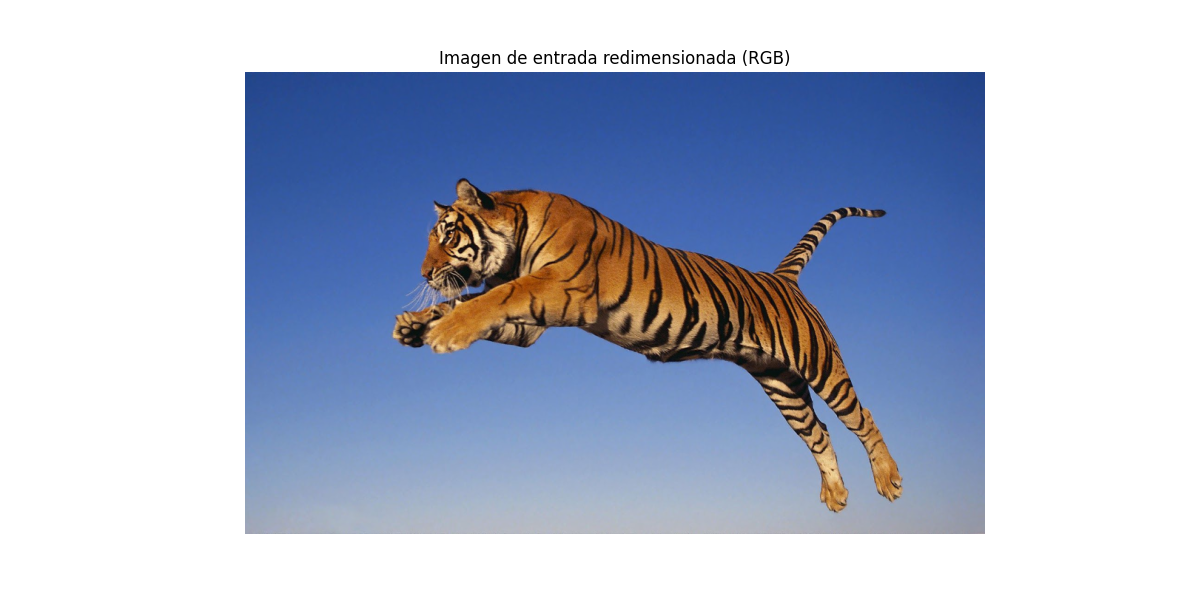

Dimensiones originales (rows, cols): 1000, 1600
Dimensiones redimensionadas (rows, cols): 625, 1000
Número de píxeles N: 625000
Shape de X_features (N, 15): (625000, 15)


In [ ]:
#@title Codigo Fase 1

# Fase 1: carga de imagen, redimensionamiento y construcción de características Lab (píxel + 4 vecinos)

# Insertar link de la imagen a segmentar
image_url = "https://raw.githubusercontent.com/juacardonahe/Interactive-Color-Segmentation-LP/refs/heads/main/images/tiger_icg_rgb.jpg"

# Cargar imagen desde URL (RGB) y escalar a [0,1]
I_rgb = io.imread(image_url)
I_rgb = img_as_float(I_rgb)

# Redimensionar a 300 px de ancho manteniendo proporción del alto
orig_rows, orig_cols = I_rgb.shape[:2]
new_width = 1000
new_height = int(round(orig_rows * new_width / orig_cols))
I_rgb = transform.resize(I_rgb, (new_height, new_width), anti_aliasing=True)

# Convertir a espacio de color CIE-Lab
I_lab = color.rgb2lab(I_rgb)

# Dimensiones de la imagen redimensionada
rows, cols = I_lab.shape[:2]
N = rows * cols  # número total de píxeles

# Padding para obtener vecinos 4-conexión (modo borde)
I_lab_pad = np.pad(I_lab, ((1, 1), (1, 1), (0, 0)), mode='edge')

# Píxel central y vecinos (arriba, abajo, izquierda, derecha)
center = I_lab_pad[1:-1, 1:-1, :]
up     = I_lab_pad[0:-2, 1:-1, :]
down   = I_lab_pad[2:  , 1:-1, :]
left   = I_lab_pad[1:-1, 0:-2, :]
right  = I_lab_pad[1:-1, 2:  , :]

# Concatenar características: [L,a,b]_central + vecinos (5 x 3 = 15)
features_lab = np.concatenate([center, up, down, left, right], axis=2)

# Reorganizar a matriz 2D de características (N x 15)
X_features = features_lab.reshape(-1, 15)

# Visualización rápida de la imagen redimensionada
plt.figure(figsize=(12, 6))
plt.imshow(I_rgb)
plt.axis('off')
plt.title("Imagen de entrada redimensionada (RGB)")
plt.show()

# Resumen de la fase 1
print(f"Dimensiones originales (rows, cols): {orig_rows}, {orig_cols}")
print(f"Dimensiones redimensionadas (rows, cols): {rows}, {cols}")
print(f"Número de píxeles N: {N}")
print(f"Shape de X_features (N, 15): {X_features.shape}")

## **Fase 2: Interacción con *scribbles* y modelado GMM de FG/BG**

En esta fase el usuario proporciona información interactiva sobre qué regiones pertenecen al **foreground (FG)** y cuáles al **background (BG)**. Esa información supervisada se obtiene mediante *scribbles* dibujados directamente sobre la imagen, y se utiliza para ajustar dos modelos de mezcla gaussiana (GMM) en el espacio de características construido en la Fase 1.

El flujo es:

1. El usuario dibuja trazos sobre el **sujeto** (FG) y sobre el **fondo** (BG).
2. A partir de esos píxeles, se extraen sus vectores de características $\mathbf{f}_i \in \mathbb{R}^{15}$
3.  Se ajustan dos GMM:

   * $p(\mathbf{f}\mid FG)$
   * $p(\mathbf{f}\mid BG)$

Estos modelos probabilísticos serán la base para definir el término de datos en la Fase 3.

$$ \\ $$

### **GMM para foreground y background**

Sea $\mathbf{f}_i$ el vector de características asociado al píxel $i$ (píxel central en CIE–Lab y sus 4 vecinos, obtenido en la Fase 1).
Con los *scribbles* definimos dos conjuntos de entrenamiento:

* Conjunto de características de foreground:
  $\{\mathbf{f}_i\}_{i \in \mathcal{S}_{FG}}$
* Conjunto de características de background:
  $\{\mathbf{f}_i\}_{i \in \mathcal{S}_{BG}}$

Sobre cada conjunto se ajusta un modelo de mezcla gaussiana con $K$ componentes:

$$
p(\mathbf{f}\mid FG) = \sum_{k=1}^{K} \pi_k^{(f)} ,
\mathcal{N}\big(\mathbf{f} \mid \boldsymbol{\mu}_k^{(f)}, \boldsymbol{\Sigma}_k^{(f)} \big),
$$

$$
p(\mathbf{f}\mid BG) = \sum_{k=1}^{K} \pi_k^{(b)} ,
\mathcal{N}\big(\mathbf{f} \mid \boldsymbol{\mu}_k^{(b)}, \boldsymbol{\Sigma}_k^{(b)} \big),
$$

donde $\pi_k$ son los pesos de mezcla, $\boldsymbol{\mu}_k$ las medias y $\boldsymbol{\Sigma}_k$ las covarianzas de cada componente.

En el código, estos modelos se almacenan como `GMM_FG` y `GMM_BG`, ajustados con `GaussianMixture` de *scikit-learn*.

$$ \\ $$

### **Uso posterior: distancias y corrección de signo**

A partir de los GMM, en la Fase 3 calculamos, para cada píxel, distancias de Mahalanobis mínimas al modelo de FG y al de BG:

* Distancia al modelo de foreground: $d_f(\mathbf{f}_i)$
* Distancia al modelo de background: $d_b(\mathbf{f}_i)$

Para definir el término de datos usamos

$$
\delta_i = d_f(\mathbf{f}_i) - d_b(\mathbf{f}_i),
$$

de manera que:

* Si el píxel se parece más al FG (menor distancia a FG), entonces $d_f < d_b$ y $\delta_i < 0$, lo que favorece $x_i \approx 1$ en la función objetivo.
* Si el píxel se parece más al BG, entonces $d_f > d_b$ y $\delta_i > 0$, lo que favorece $x_i \approx 0$.

En el artículo original la notación lleva a usar el signo contrario para $\delta_i$, lo que haría que los píxeles más parecidos al foreground fuesen penalizados como fondo. En esta implementación **corregimos ese cambio de signo** para que la interpretación del término de datos sea coherente y la segmentación favorezca correctamente al sujeto marcado como foreground.

Con esto, la Fase 2 deja listos los modelos probabilísticos $p(\mathbf{f}\mid FG)$ y $p(\mathbf{f}\mid BG)$, así como los índices de píxeles etiquetados, que serán utilizados en la Fase 3 para construir el término $\delta_i$ y el funcional de energía del problema de optimización lineal.


Output()

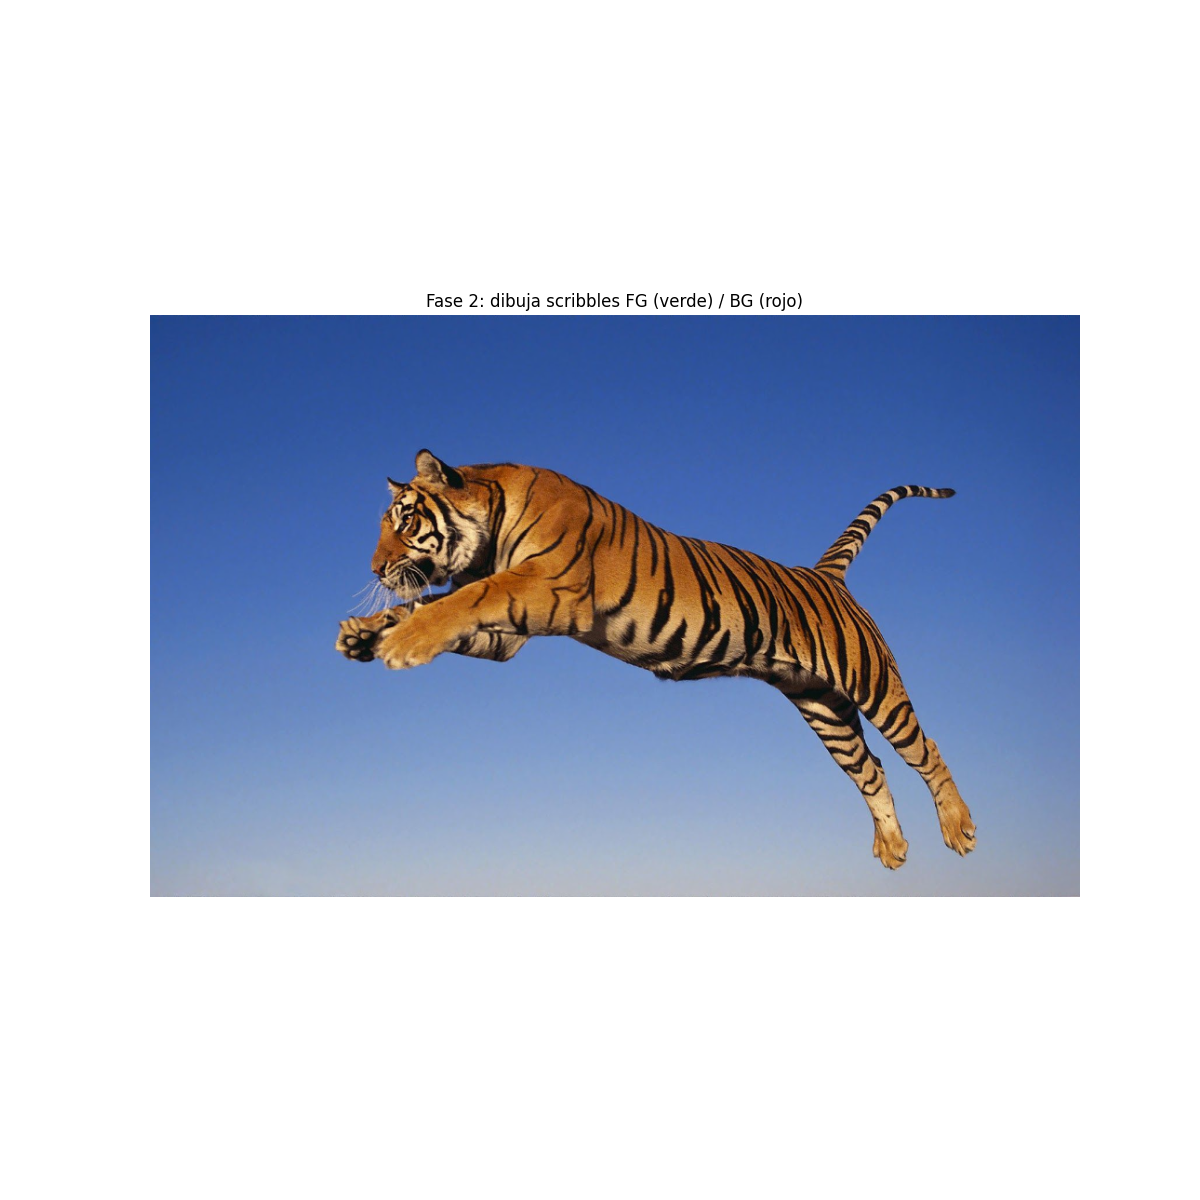

In [ ]:
#@title Codigo Fase 2
# Fase 2: interfaz interactiva de scribbles y ajuste de GMM para FG/BG

# Coordenadas de píxeles para selección con Lasso
x_grid, y_grid = np.meshgrid(np.arange(cols), np.arange(rows))
pixel_coords = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

# Máscaras de scribbles para foreground y background
foreground_scribble_mask = np.zeros((rows, cols), dtype=bool)
background_scribble_mask = np.zeros((rows, cols), dtype=bool)

# Contenedores para los modelos GMM
GMM_FG = None
GMM_BG = None
fg_indices = None
bg_indices = None

# Estado de etiqueta actual (FG o BG)
current_label = {"value": "FG"}

# Figura e imagen
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(I_rgb)
ax.set_title("Fase 2: dibuja scribbles FG (verde) / BG (rojo)")
ax.axis("off")

scribble_lines = []

def onselect_lasso(verts):
    # Actualiza máscaras de scribbles a partir del lasso
    path = MplPath(verts)
    inside = path.contains_points(pixel_coords).reshape(rows, cols)

    if current_label["value"] == "FG":
        foreground_scribble_mask[inside] = True
        line_color = "lime"
    else:
        background_scribble_mask[inside] = True
        line_color = "red"

    # Dibuja la trayectoria del lasso sobre la imagen
    line = plt.Line2D([v[0] for v in verts], [v[1] for v in verts],
                      linewidth=2, color=line_color)
    ax.add_line(line)
    scribble_lines.append(line)

    fig.canvas.draw_idle()

# LassoSelector para dibujar scribbles
lasso = LassoSelector(ax, onselect_lasso)

# Widgets para control de etiqueta y acciones
btn_fg = widgets.ToggleButton(description="Foreground (FG)", value=True)
btn_bg = widgets.ToggleButton(description="Background (BG)", value=False)
btn_clear = widgets.Button(description="Limpiar scribbles")
btn_fit = widgets.Button(description="Ajustar GMM")

output_fit = widgets.Output()

def on_fg_toggle(change):
    # Cambia etiqueta actual a FG
    if change["new"]:
        current_label["value"] = "FG"
        btn_bg.value = False

def on_bg_toggle(change):
    # Cambia etiqueta actual a BG
    if change["new"]:
        current_label["value"] = "BG"
        btn_fg.value = False

def on_clear_clicked(b):
    # Limpia scribbles y máscaras
    global foreground_scribble_mask, background_scribble_mask
    foreground_scribble_mask[:] = False
    background_scribble_mask[:] = False

    for line in scribble_lines:
        line.remove()
    scribble_lines.clear()

    fig.canvas.draw_idle()
    with output_fit:
        clear_output()
        print("Scribbles eliminados.")

def on_fit_clicked(b):
    # Ajusta GMM para FG y BG a partir de los scribbles
    global GMM_FG, GMM_BG, fg_indices, bg_indices

    fg_indices = np.where(foreground_scribble_mask.ravel())[0]
    bg_indices = np.where(background_scribble_mask.ravel())[0]

    with output_fit:
        clear_output()

        if fg_indices.size == 0 or bg_indices.size == 0:
            print("Se requieren scribbles en FG y BG antes de ajustar los GMM.")
            return

        X_fg = X_features[fg_indices]
        X_bg = X_features[bg_indices]

        # Ajuste de GMM para FG y BG
        GMM_FG = GaussianMixture(
            n_components=5,
            covariance_type="full",
            random_state=0
        ).fit(X_fg)

        GMM_BG = GaussianMixture(
            n_components=5,
            covariance_type="full",
            random_state=0
        ).fit(X_bg)

        print("GMM ajustados correctamente.")
        print(f"Muestras FG: {X_fg.shape[0]}, muestras BG: {X_bg.shape[0]}")
        print("Modelos disponibles en: GMM_FG, GMM_BG")
        print("Índices de píxeles en: fg_indices, bg_indices")

# Conectar callbacks
btn_fg.observe(on_fg_toggle, names="value")
btn_bg.observe(on_bg_toggle, names="value")
btn_clear.on_click(on_clear_clicked)
btn_fit.on_click(on_fit_clicked)

# Layout de controles
controls = widgets.HBox([btn_fg, btn_bg, btn_clear, btn_fit])
display(controls, output_fit)
plt.show()


## **Fase 3: Cálculo del término de datos $\delta_i$ y de los pesos de suavizado $w_{ij}$**

En esta fase se construyen los términos de energía que alimentan el problema de optimización lineal:

* El **término de datos**, que indica para cada píxel si es más probable que pertenezca al foreground o al background.
* El **término de suavizado**, que penaliza cambios bruscos de etiqueta entre píxeles vecinos con colores similares.

Partimos de:

* La matriz de características $X_{\text{features}} \in \mathbb{R}^{N \times 15}$ de la Fase 1.
* Los modelos GMM `GMM_FG` y `GMM_BG` ajustados en la Fase 2.

$$ \\ $$

### **Término de datos: definición de $\delta_i$**

Para cada píxel con vector de características $\mathbf{f}_i$ calculamos las distancias de Mahalanobis mínimas a los GMM de foreground y background:

* Distancia al modelo de foreground: $d_f(\mathbf{f}_i)$
* Distancia al modelo de background: $d_b(\mathbf{f}_i)$

El término de datos se define como:

$$
\delta_i = d_f(\mathbf{f}_i) - d_b(\mathbf{f}_i)
$$

Con esta convención:

* Si el píxel se parece más al foreground (menor distancia a FG), entonces
  $d_f(\mathbf{f}_i) < d_b(\mathbf{f}_i) \Rightarrow \delta_i < 0$,
  lo que favorece $x_i \approx 1$ (FG) en la función objetivo.
* Si el píxel se parece más al background, entonces
  $d_f(\mathbf{f}_i) > d_b(\mathbf{f}_i) \Rightarrow \delta_i > 0$,
  lo que favorece $x_i \approx 0$ (BG).

Esta definición corrige el cambio de signo respecto a la notación original del artículo, de forma que el término de datos es coherente con la interpretación de $x_i$ como probabilidad “suavizada” de pertenecer al foreground.

En el notebook, los valores se almacenan como:

* `delta_flat`: vector de tamaño $N$ con los $\delta_i$ aplanados.
* `delta_image`: matriz de tamaño $(\texttt{rows}, \texttt{cols})$ con los mismos valores reordenados en forma de imagen.

$$ \\ $$

### **Término de suavizado: pesos $w_{ij}$ entre píxeles vecinos**

Para imponer suavidad espacial se construye un grafo de 4-neighbors sobre la imagen:

* Cada píxel es un nodo.
* Se conectan pares vecinos ${i,j}$ a la derecha y hacia abajo, formando las aristas del grafo.

Si denotamos por $I_i \in \mathbb{R}^3$ el vector Lab del píxel $i$, la diferencia de color entre dos vecinos $i$ y $j$ es:

$$
\Delta I_{ij} = I_i - I_j
$$

y su norma cuadrática:

$$
\lVert \Delta I_{ij} \rVert^2 = \Delta I_{ij}^\top \Delta I_{ij}.
$$

A partir de estas diferencias se calcula un parámetro de escala $\sigma$ basado en la media de las distancias:

$$
\sigma = 2 , \sqrt{\mathbb{E}\big[ \lVert \Delta I_{ij} \rVert^2 \big]}
$$

y se definen los pesos de suavizado:

$$
w_{ij} = \exp\left( -\frac{\lVert \Delta I_{ij} \rVert^2}{2 \sigma^2} \right)
$$

De este modo:

* Píxeles vecinos con colores muy similares tienen $w_{ij} \approx 1$ y se penaliza fuertemente que cambien de etiqueta.
* Píxeles vecinos con colores muy distintos tienen $w_{ij} \approx 0$ y se permite mayor libertad para que sus etiquetas difieran.

En el notebook, el grafo se representa con:

* `neighbors_i` y `neighbors_j`: vectores de tamaño $M$ con los índices de los píxeles conectados (cada par ${i,j}$).
* `w_ij`: vector de tamaño $M$ con el peso $w_{ij}$ de cada arista.

---

### **Resultado de la Fase 3**

Al finalizar esta fase contamos con todos los términos necesarios para formular el problema LP de la Fase 4:

* `delta_flat` y `delta_image`: término de datos $\delta_i$ para cada píxel.
* `neighbors_i`, `neighbors_j`: estructura del grafo de 4-vecinos.
* `w_ij`: pesos de suavizado entre píxeles vecinos.
* `sigma`: parámetro de escala utilizado en el cálculo de los pesos.

Estos elementos se incorporan en la función objetivo:

$$
\min_x \sum_i \delta_i x_i + \lambda \sum_{(i,j)} w_{ij} , \lvert x_i - x_j \rvert
$$

cuyas variables y restricciones se construirán explícitamente en la Fase 4.


In [ ]:
#@title Codigo Fase 3

# Fase 3: cálculo de δ_i y pesos w_ij (4-conexión)

# Verificación básica de modelos GMM
if GMM_FG is None or GMM_BG is None:
    raise RuntimeError("GMM_FG y GMM_BG deben estar ajustados en la Fase 2.")

# Función para obtener la distancia de Mahalanobis mínima a un GMM
def min_mahalanobis_to_gmm(X, gmm):
    # X: (N, D), gmm.means_: (K, D), gmm.covariances_: (K, D, D)
    means = gmm.means_
    covs = gmm.covariances_
    n_components = means.shape[0]

    maha_all = np.empty((X.shape[0], n_components), dtype=float)

    for k in range(n_components):
        mu_k = means[k]
        cov_k = covs[k]
        cov_inv_k = np.linalg.inv(cov_k)
        diff = X - mu_k
        tmp = diff @ cov_inv_k
        maha2 = np.einsum("ij,ij->i", tmp, diff)
        maha_all[:, k] = np.sqrt(np.maximum(maha2, 0.0))

    return maha_all.min(axis=1)


# Distancias df y db para cada píxel
df = min_mahalanobis_to_gmm(X_features, GMM_FG)  # foreground
db = min_mahalanobis_to_gmm(X_features, GMM_BG)  # background

# δ_i = df - db  (FG más probable → δ_i < 0)
delta_flat = df - db
delta_image = delta_flat.reshape(rows, cols)

# comprobacion
fg_delta = delta_flat[fg_indices]
bg_delta = delta_flat[bg_indices]
print("δ promedio FG:", fg_delta.mean())
print("δ promedio BG:", bg_delta.mean())


print("Fase 3: δ_i calculado.")
print(f"delta_flat shape: {delta_flat.shape}")
print(f"delta_image shape: {delta_image.shape}")

# ---------------- Pesos w_ij (4 vecinos) ---------------- #

# Aplanar Lab para diferencias de color
I_flat = I_lab.reshape(-1, 3)

# Índices de píxel en rejilla
idx_grid = np.arange(N).reshape(rows, cols)

# Pares de vecinos (derecha y abajo para no duplicar)
pairs_i_right = idx_grid[:, :-1].ravel()
pairs_j_right = idx_grid[:, 1:  ].ravel()

pairs_i_down  = idx_grid[:-1, :].ravel()
pairs_j_down  = idx_grid[1:  , :].ravel()

neighbors_i = np.concatenate([pairs_i_right, pairs_i_down])
neighbors_j = np.concatenate([pairs_j_right, pairs_j_down])

# Diferencias de color en Lab
diff = I_flat[neighbors_i] - I_flat[neighbors_j]
dist2 = np.einsum("ij,ij->i", diff, diff)

# σ basado en la media de las diferencias
mean_dist2 = dist2.mean()
sigma = 2.0 * np.sqrt(mean_dist2 + 1e-12)

# Pesos w_ij según Eq. (15)
w_ij = np.exp(-dist2 / (2.0 * sigma**2))

print("Fase 3: pesos w_ij calculados.")
print(f"Cantidad de aristas vecinas: {neighbors_i.shape[0]}")
print(f"sigma usado: {sigma:.6f}")

# Variables clave para la siguiente fase:
# delta_flat (N,) y delta_image (rows, cols)
# neighbors_i, neighbors_j (indices de píxeles vecinos)
# w_ij (peso por par de píxeles vecinos)

δ promedio FG: -0.10575319863448894
δ promedio BG: 0.026794505461361622
Fase 3: δ_i calculado.
delta_flat shape: (625000,)
delta_image shape: (625, 1000)
Fase 3: pesos w_ij calculados.
Cantidad de aristas vecinas: 1248375
sigma usado: 9.413215




## **Fase 4: Formulación del problema de Optimización Lineal**

En esta fase se construye el problema de **Optimización lineal (LP)** que combina:

* El **término de datos** $\delta_i$ calculado en la Fase 3.
* El **término de suavizado** con pesos $w_{ij}$ entre píxeles vecinos.
* Las **restricciones** impuestas por los *scribbles* de foreground (FG) y background (BG).

El objetivo es obtener un valor continuo $x_i \in [0,1]$ por píxel, que luego se binarizará.

$$ \\ $$

### **Variables de decisión**

Se introduce una variable $x_i$ por cada píxel $i = 1, \dots, N$:

* $x_i \approx 1$ indica preferencia por FG.
* $x_i \approx 0$ indica preferencia por BG.

Para linealizar el término absoluto $\lvert x_i - x_j \rvert$ se introduce además una variable auxiliar $y_k \ge 0$ por cada par de vecinos $(i,j)$, con índice de arista $k = 1, \dots, M$.

El vector completo de variables se escribe como:

$$
\mathbf{z} =
\begin{bmatrix}
\mathbf{x} \
\mathbf{y}
\end{bmatrix}
\in \mathbb{R}^{N+M},
\qquad
\mathbf{x} \in [0,1]^N,\ \mathbf{y} \in [0,+\infty)^M.
$$

$$ \\ $$

### **Función objetivo**

La energía a minimizar es:

$$
E(\mathbf{x}) =
\sum_{i=1}^{N} \delta_i x_i
+
\lambda \sum_{(i,j)} w_{ij} \lvert x_i - x_j \rvert,
$$

donde $\lambda > 0$ controla el compromiso entre fidelidad a los datos y suavidad de la segmentación.

Tras introducir las variables $y_k$, el objetivo se vuelve lineal:

$$
\min_{\mathbf{x}, \mathbf{y}}
\ \sum_{i=1}^{N} \delta_i x_i
+
\lambda \sum_{k=1}^{M} w_k y_k
$$

y se implementa como un vector de costos:

$$
\mathbf{c} =
\begin{bmatrix}
\boldsymbol{\delta} \
\lambda,\mathbf{w}
\end{bmatrix}
\in \mathbb{R}^{N+M}.
$$

$$ \\ $$

### **Linealización del término absoluto**

Para cada arista $k$ que conecta los píxeles $i$ y $j$, se impone:

$$
y_k \ge x_i - x_j, \qquad
y_k \ge -x_i + x_j.
$$

Estas desigualdades aseguran que

$$
y_k \ge \lvert x_i - x_j \rvert
$$

y, como el objetivo minimiza $y_k$, en el óptimo se cumple $y_k = \lvert x_i - x_j \rvert$.

En forma estándar de restricciones del tipo $A_{\text{ub}} \mathbf{z} \le \mathbf{b}_{\text{ub}}$:

* $x_i - x_j - y_k \le 0,$
* $-x_i + x_j - y_k \le 0.$

Estas dos filas se construyen para cada una de las $M$ aristas del grafo de 4-vecinos.

$$ \\ $$

### **Restricciones de *scribbles* (igualdades)**

Los *scribbles* fijan el valor de $x_i$ en los píxeles dibujados:

* Si el píxel $i$ está marcado como foreground (FG):

  $$
  x_i = 1.
  $$

* Si el píxel $i$ está marcado como background (BG):

  $$
  x_i = 0.
  $$

Estas restricciones se escriben como un sistema de igualdades:

$$
A_{\text{eq}} \mathbf{z} = \mathbf{b}_{\text{eq}},
$$

donde:

* Cada fila de $A_{\text{eq}}$ tiene un 1 en la posición correspondiente a $x_i$ y ceros en el resto de columnas.
* $\mathbf{b}_{\text{eq}}$ contiene 1 para los píxeles FG y 0 para los píxeles BG.

Antes de construir estas ecuaciones se corrigen posibles solapamientos de scribbles (píxeles marcados simultáneamente como FG y BG), dando prioridad al foreground para evitar un sistema de igualdades contradictorio.

$$ \\ $$

### **Cotas de las variables**

Se definen las cotas:

* Para los píxeles:

  $$
  0 \le x_i \le 1, \quad i = 1,\dots,N.
  $$

* Para las variables auxiliares:

  $$
  0 \le y_k < +\infty, \quad k = 1,\dots,M.
  $$

Estas cotas se pasan al solver como una lista de intervalos para cada componente de $\mathbf{z}$.

$$ \\ $$

### **Forma matricial para el solver LP**

En resumen, el problema que se entrega a `scipy.optimize.linprog` tiene la forma:

$$
\begin{aligned}
\min_{\mathbf{z}} \quad & \mathbf{c}^\top \mathbf{z} \\
\text{sujeto a} \quad
& A_{\text{ub}} \mathbf{z} \le \mathbf{b}_{\text{ub}} \\
& A_{\text{eq}} \mathbf{z} = \mathbf{b}_{\text{eq}} \\
& \text{bounds}_k^{\text{(low)}} \le z_k \le \text{bounds}_k^{\text{(high)}}
\end{aligned}
$$

donde:

* $\mathbf{z} = [\mathbf{x}; \mathbf{y}] \in \mathbb{R}^{N+M}$,
* $\mathbf{c} = [\boldsymbol{\delta}; \lambda \mathbf{w}]$,
* $A_{\text{ub}}$ recoge las restricciones linealizadas de $\lvert x_i - x_j \rvert$,
* $A_{\text{eq}}$ fija los píxeles etiquetados por los *scribbles*.

---

### **Resultado de la Fase 4**

El solver devuelve una solución óptima $\mathbf{z}^*$; de ella se extrae:

$$
\mathbf{x}^* = \big( x_1^*, x_2^*, \dots, x_N^* \big),
$$

que se reordena a forma de imagen:

$$
x^*_{\text{image}} \in \mathbb{R}^{\texttt{rows} \times \texttt{cols}}.
$$

Esta imagen de probabilidades suaves $x_i^*$ es la entrada de la **Fase 5**, donde se realiza la binarización (FG/BG) y se construye la máscara final de segmentación.


In [ ]:
#@title Codigo Fase 4

# Fase 4: construcción del LP y solución para obtener x_i

# Parámetro de suavizado lambda
lambda_smooth = 50.0

# Verificación básica de dimensiones
assert delta_flat.shape[0] == N, "delta_flat debe tener tamaño N."
M = neighbors_i.shape[0]
assert neighbors_j.shape[0] == M and w_ij.shape[0] == M, "Dimensiones inconsistentes en vecinos."

# Aplanar máscaras de scribbles
fg_mask_flat = foreground_scribble_mask.ravel().copy()
bg_mask_flat = background_scribble_mask.ravel().copy()

# Corrección de solapamientos FG/BG (prioridad al FG)
overlap = fg_mask_flat & bg_mask_flat
if np.any(overlap):
    bg_mask_flat[overlap] = False
    background_scribble_mask = bg_mask_flat.reshape(rows, cols)
    print(f"Fase 4: se corrigieron {overlap.sum()} píxeles con solapamiento FG/BG (FG tiene prioridad).")

# Índices de scribbles
fg_indices = np.where(fg_mask_flat)[0]
bg_indices = np.where(bg_mask_flat)[0]

if fg_indices.size == 0 or bg_indices.size == 0:
    raise RuntimeError("Se requieren scribbles de FG y BG antes de Fase 4.")

# Número de variables
n_x = N
n_y = M
n_vars = n_x + n_y

# Vector de costos c
c = np.zeros(n_vars, dtype=float)
c[:n_x] = delta_flat
c[n_x:] = lambda_smooth * w_ij

# ---------------- Restricciones de |x_i - x_j| ---------------- #

rows_ub = []
cols_ub = []
data_ub = []

# x_i - x_j - y_k <= 0
for k in range(M):
    i = neighbors_i[k]
    j = neighbors_j[k]
    y_idx = n_x + k
    row = 2 * k

    rows_ub.extend([row, row, row])
    cols_ub.extend([i,   j,   y_idx])
    data_ub.extend([1.0, -1.0, -1.0])

# -x_i + x_j - y_k <= 0
for k in range(M):
    i = neighbors_i[k]
    j = neighbors_j[k]
    y_idx = n_x + k
    row = 2 * k + 1

    rows_ub.extend([row, row, row])
    cols_ub.extend([i,   j,   y_idx])
    data_ub.extend([-1.0, 1.0, -1.0])

n_ub = 2 * M
A_ub = sparse.coo_matrix((data_ub, (rows_ub, cols_ub)), shape=(n_ub, n_vars)).tocsr()
b_ub = np.zeros(n_ub, dtype=float)

# ---------------- Restricciones de scribbles (igualdades) ---------------- #

scribble_idx = np.concatenate([fg_indices, bg_indices])
scribble_vals = np.concatenate([
    np.ones_like(fg_indices, dtype=float),
    np.zeros_like(bg_indices, dtype=float)
])

n_eq = scribble_idx.shape[0]
rows_eq = np.arange(n_eq)
cols_eq = scribble_idx
data_eq = np.ones(n_eq, dtype=float)

A_eq = sparse.coo_matrix((data_eq, (rows_eq, cols_eq)), shape=(n_eq, n_vars)).tocsr()
b_eq = scribble_vals

# ---------------- Cotas ---------------- #

bounds = [(0.0, 1.0)] * n_x + [(0.0, None)] * n_y

# ---------------- Resolver LP ---------------- #

res = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

if (res is None) or (res.x is None) or (not res.success):
    raise RuntimeError(f"LP no devolvió solución válida. Mensaje del solver: {res.message}")

print("Fase 4: LP resuelto correctamente.")
print("Valor objetivo:", res.fun)

# Solución x_i
x_sol_flat = res.x[:n_x]
x_sol_image = x_sol_flat.reshape(rows, cols)

print(f"x_sol_flat shape: {x_sol_flat.shape}")
print(f"x_sol_image shape: {x_sol_image.shape}")


Fase 4: se corrigieron 102100 píxeles con solapamiento FG/BG (FG tiene prioridad).
Fase 4: LP resuelto correctamente.
Valor objetivo: 83843.68165174303
x_sol_flat shape: (625000,)
x_sol_image shape: (625, 1000)


## **Fase 5: Solución del LP, binarización y visualización de la segmentación**

En esta fase se toman los resultados del problema de optimización lineal planteado en la Fase 4 y se obtienen directamente las máscaras de segmentación y las visualizaciones finales. Corresponde a los pasos 4–5 del Algoritmo 1 del artículo.

El solver LP devuelve el vector de variables óptimas:
$$
\mathbf{z}^* =
\begin{bmatrix}
\mathbf{x}^* \\
\mathbf{y}^*
\end{bmatrix},
$$
donde $\mathbf{x}^* \in [0,1]^N$ contiene, para cada píxel, un valor continuo que puede interpretarse como una "probabilidad suavizada" de pertenecer al foreground.

$$ \\ $$

### **1. Reconstrucción de $x_i^*$ en forma de imagen**
A partir del vector $\mathbf{x}^*$ se reconstruye una imagen 2D:
$$
x^*_{\text{image}}(p,q) = x_i^*, \quad i \leftrightarrow (p,q),
$$
de tamaño $\texttt{rows} \times \texttt{cols}$, donde cada posición tiene un valor en $[0,1]$. Esta imagen se interpreta como un mapa de probabilidad de foreground.

$$ \\ $$

### **2. Binarización: máscara FG/BG**
Para obtener una segmentación binaria se aplica un umbral (por defecto, $0.5$):

* Píxel clasificado como **foreground (FG)** si $x_i^* \ge 0.5$.
* Píxel clasificado como **background (BG)** si $x_i^* < 0.5$.

Esto da lugar a la máscara binaria:
$$
M(p,q) =
\begin{cases}
1, & \text{si } x^*_{\text{image}}(p,q) \ge 0.5, \\
0, & \text{en otro caso},
\end{cases}
$$
con el mismo tamaño que la imagen original. En el notebook esta máscara se representa como `mask_fg` (para FG) y `mask_bg` (para BG).

> **Nota:** Para mantener la coherencia con la interacción del usuario, se refuerzan los *scribbles*: los píxeles marcados originalmente como FG/BG se fuerzan a 1/0 respectivamente, incluso después del LP.

$$ \\ $$

### **3. Visualización de resultados**
Con la máscara binaria se generan directamente las visualizaciones finales:

1.  **Imagen original con FG resaltado:** Se toma la imagen original $I_{\text{RGB}}$ y se mezcla el color de los píxeles etiquetados como FG con un tono verde, obteniendo una vista de la segmentación superpuesta sobre la escena original.
2.  **Foreground (FG) aislado:** Se multiplica la imagen por la máscara FG:
    $$
    I_{\text{FG}}(p,q,:) = I_{\text{RGB}}(p,q,:) \cdot M(p,q),
    $$
    de modo que solo se muestran los píxeles del objeto segmentado, y el fondo queda negro (o transparente).
3.  **Background (BG) aislado (opcional):** De forma análoga, se puede visualizar únicamente el fondo:
    $$
    I_{\text{BG}}(p,q,:) = I_{\text{RGB}}(p,q,:) \cdot (1 - M(p,q)).
    $$

En el notebook, esta fase reconstruye $x^*_{\text{image}}$, genera la máscara binaria $M$ y muestra las figuras finales (Probabilidad, Overlay y Objeto aislado), completando el flujo de segmentación interactiva.

Fase 5: segmentación binaria generada.
mask_fg shape: (625, 1000), dtype: bool


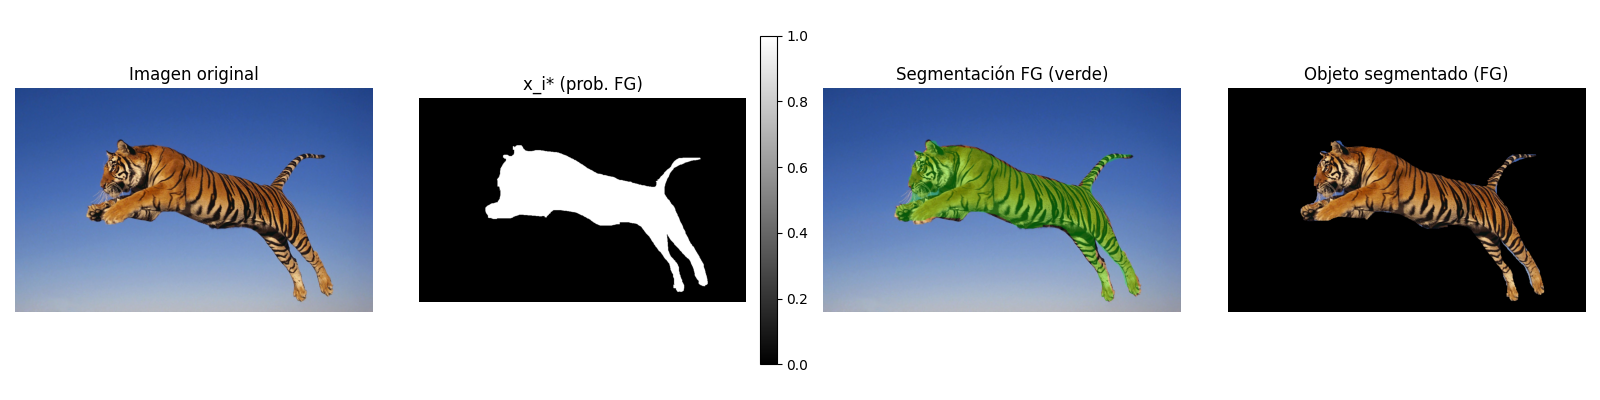

In [ ]:
#@title Codigo Fase 5

# Fase 5: redondeo de x_i*, máscara binaria y visualización de segmentación

# Verificación de solución LP
if "x_sol_image" not in globals():
    raise RuntimeError("x_sol_image no está definido. Ejecuta la Fase 4 antes de esta celda.")

# Umbral de binarización
threshold_fg = 0.5

# Asegurar rango [0,1]
x_prob = np.clip(x_sol_image, 0.0, 1.0)

# Máscara binaria FG/BG
mask_fg = x_prob >= threshold_fg
mask_bg = ~mask_fg

# Reforzar scribbles (FG=1, BG=0)
mask_fg[foreground_scribble_mask] = True
mask_bg[foreground_scribble_mask] = False

mask_fg[background_scribble_mask] = False
mask_bg[background_scribble_mask] = True

# Imagen del FG aislado
fg_only = I_rgb * mask_fg[..., np.newaxis]

print("Fase 5: segmentación binaria generada.")
print(f"mask_fg shape: {mask_fg.shape}, dtype: {mask_fg.dtype}")

# Visualización: original, probabilidad y segmentación
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Imagen original
axes[0].imshow(I_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

# Mapa de probabilidad x_i*
im0 = axes[1].imshow(x_prob, cmap="gray", vmin=0.0, vmax=1.0)
axes[1].set_title("x_i* (prob. FG)")
axes[1].axis("off")
fig.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)

# Overlay de FG sobre la imagen
overlay = I_rgb.copy()
overlay[mask_fg] = 0.7 * overlay[mask_fg] + 0.3 * np.array([0.0, 1.0, 0.0])

axes[2].imshow(overlay)
axes[2].set_title("Segmentación FG (verde)")
axes[2].axis("off")

axes[3].imshow(fg_only)
axes[3].set_title("Objeto segmentado (FG)")
axes[3].axis("off")

plt.tight_layout()
plt.show()
